# Sentimental Analysis
In this project, I will analyze and visualize sentiment patterns in social media data to understand public opinion and attitudes towards specific topics or brands.

In [2]:
# Import libraries
import pandas as pd
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud 
import seaborn as sns
import random

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import joblib
import warnings
warnings.filterwarnings("ignore")

**Loading Training Data, Testing Data**

In [3]:
# Load data - training and testing
train_path = Path("twitter_training.csv")
valid_path = Path("twitter_validation.csv")

# Store DataFrames
dfs = []

# Load training data
if train_path.exists():
    training = pd.read_csv(train_path)
    # unify column names
    if training.shape[1] == 4:
        training.columns = ['tweet_id', 'entity', 'sentiment', 'text']
    dfs.append(training)
else:
    raise FileNotFoundError("Training file not found")

# Load test data
if valid_path.exists():
    validation = pd.read_csv(valid_path)
    # unify column names
    if validation.shape[1] == 4:
        validation.columns = ['tweet_id', 'entity', 'sentiment', 'text']
    dfs.append(validation)
else:
    raise FileNotFoundError("Validation file not found")

# Combine all DataFrames
data = pd.concat(dfs, ignore_index=True)

# Display the first few rows of the combined DataFrame
display(data.columns)
display(data.head())

Index(['tweet_id', 'entity', 'sentiment', 'text'], dtype='object')

,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


## Data Cleaning
**Basic cleaning and preprocessing**
- Removing URLs
- Remove twitter handles
- Remove RT markers
- Collapse whitespaces
- Normalize text (e.g., lowercase)
- Merge Irrelevant to Neutral
- Removing nulls

In [4]:
import re
# Data Cleaning
def cleaning_data(s: str) -> str:
    s = str(s)
    # remove URLs
    s = re.sub(r"http\S+|www\S+|https\S+", "", s, flags=re.MULTILINE)
    # remove twitter handles
    s = re.sub(r"@\w+", "", s)
    # remove RT markers
    s = re.sub(r"\bRT\b", "", s)
    # collapse whitespaces
    s = re.sub(r"\s+", " ", s).strip()
    # normalize text
    s = s.lower()
    return s
# Apply cleaning function to text data
data['text'] = data['text'].astype(str).apply(cleaning_data)

# Title-case and notmalize sentiment labels
data['sentiment'] = data['sentiment'].astype(str).str.strip().str.title()

# Merge Irrelevant to Neutral
data['sentiment'] = data['sentiment'].replace({'Irrelevant': 'Neutral'})

# Remove nulls
data = data.dropna(subset=['text', 'sentiment', 'entity']).reset_index(drop=True)
data = data[data['text'].str.len()>2].reset_index(drop=True)
# Remove duplicates
data = data.drop_duplicates().reset_index(drop=True)
print('Shape after cleaning:', data.shape)


Shape after cleaning: (70942, 4)


We removes URLs, RT markers since they do not contribute to the sentiment analysis.

## Exploratory Data Analysis

sentiment
Neutral     29979
Negative    21488
Positive    19475
Name: count, dtype: int64

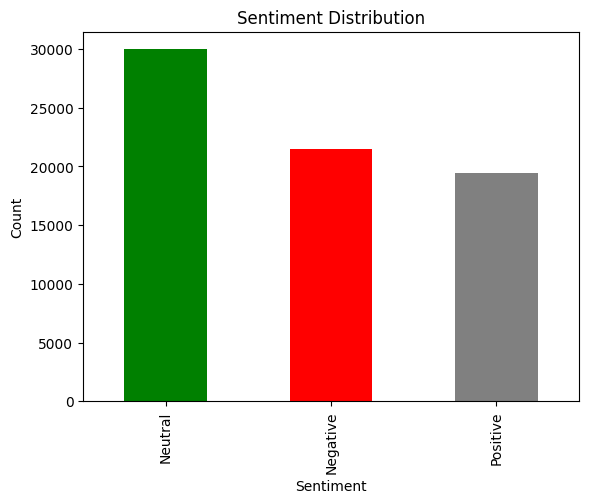

In [5]:
# Plotting sentiment distribution
display(data['sentiment'].value_counts())

# Visualize the class balance
data['sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'gray', 'blue'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

There is a class imbalance in the training data, with a higher number of neutral tweets compared to positive and negative tweets

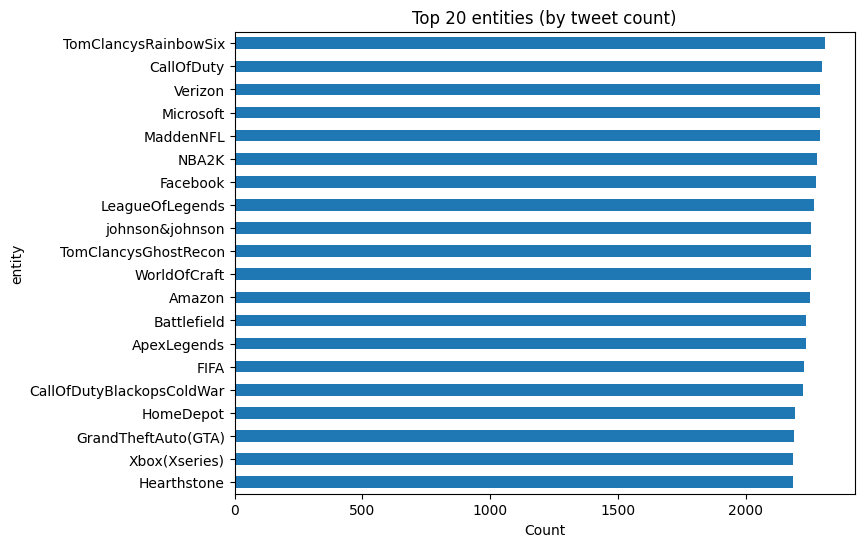

In [6]:
# Visualizing top entities
top_entities = data["entity"].value_counts().head(20)
plt.figure(figsize=(8,6))
top_entities.plot(kind="barh")
plt.title("Top 20 entities (by tweet count)")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.show()

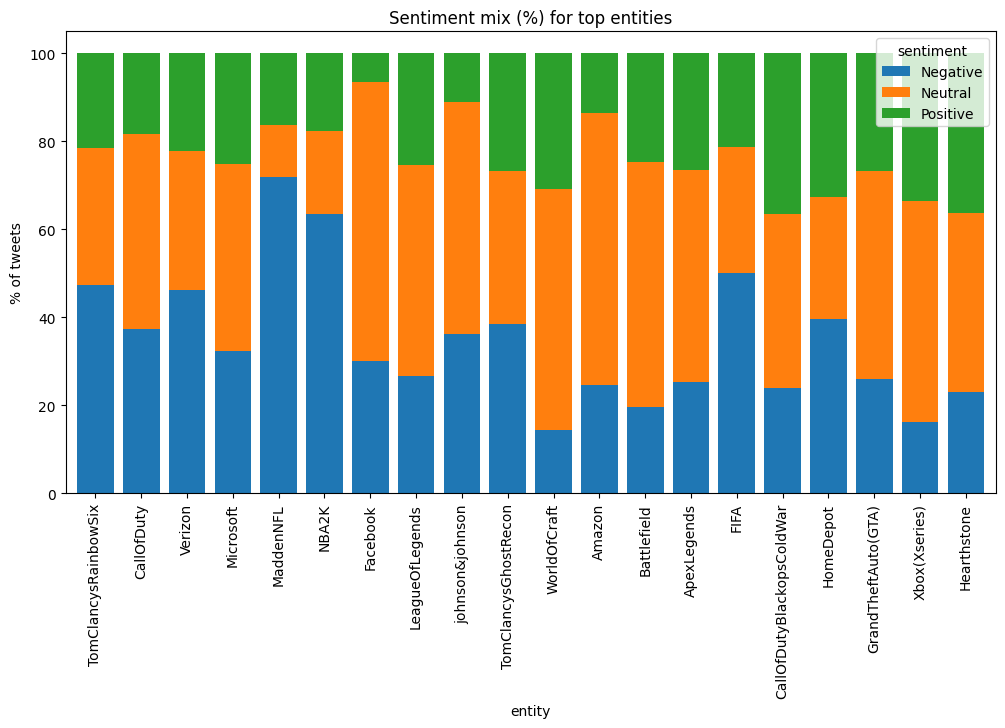

In [7]:
# Visualizing sentiments per top 20 entities
pivot = data.groupby(["entity","sentiment"]).size().unstack(fill_value=0)
top_entities_list = top_entities.index
pivot_top = pivot.loc[top_entities_list]
(pivot_top.div(pivot_top.sum(axis=1), axis=0) * 100).plot(
    kind="bar", stacked=True, figsize=(12,6), width=0.8
)
plt.ylabel("% of tweets")
plt.title("Sentiment mix (%) for top entities")
plt.show()

- `Call of duty` received more positive sentiment compared to other entities.
- `MaddenNFL` received more negative sentiment compared to other entities.

- **Words per n-gram insights** - find common words/phrases used in each sentiment category.
- **Identify word patterns** - to see which words appear frequently in each sentiment category.


Top unigrams for Positive
[('game', np.int64(2268)), ('com', np.int64(1892)), ('love', np.int64(1714)), ('just', np.int64(1670)), ('good', np.int64(1552)), ('like', np.int64(1330)), ('pic', np.int64(1293)), ('really', np.int64(1265)), ('new', np.int64(1197)), ('twitter', np.int64(1116)), ('best', np.int64(1102)), ('play', np.int64(1016)), ('time', np.int64(993)), ('great', np.int64(952)), ('playing', np.int64(921))]
Top bigrams:
[('twitter com', np.int64(1074)), ('pic twitter', np.int64(1049)), ('red dead', np.int64(581)), ('dead redemption', np.int64(484)), ('assassin creed', np.int64(339)), ('twitch tv', np.int64(328)), ('home depot', np.int64(325)), ('assassins creed', np.int64(224)), ('xbox series', np.int64(220)), ('black ops', np.int64(202))]

Top unigrams for Neutral
[('com', np.int64(5984)), ('just', np.int64(2749)), ('game', np.int64(2126)), ('like', np.int64(1902)), ('johnson', np.int64(1902)), ('unk', np.int64(1446)), ('facebook', np.int64(1434)), ('amazon', np.int64(1430))

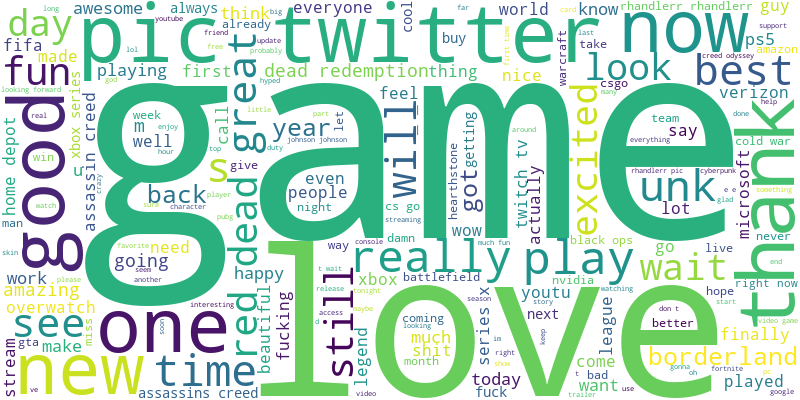

In [8]:
# Function to extract top n-grams
def top_ngrams(corpus, ngram_range=(1,1), top_k=20):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words="english", min_df=5)
    X = vec.fit_transform(corpus)
    sums = X.sum(axis=0).A1
    terms = np.array(vec.get_feature_names_out())
    top_idx = sums.argsort()[::-1][:top_k]
    return list(zip(terms[top_idx], sums[top_idx]))

for label in data["sentiment"].unique():
    print("\nTop unigrams for", label)
    uni = top_ngrams(data.loc[data["sentiment"]==label, "text"], (1,1), top_k=15)
    print(uni)
    print("Top bigrams:")
    bi = top_ngrams(data.loc[data["sentiment"]==label, "text"], (2,2), top_k=10)
    print(bi)

# Visualizing word clouds for each sentiment
positive_tweets = " ".join(data[data['sentiment'] == "Positive"]['text'])
negative_tweets = " ".join(data[data['sentiment'] == "Negative"]['text'])

# Wordcloud for positive
WordCloud(width=800, height=400, background_color='white').generate(positive_tweets).to_image()

**Modeling**

In [9]:
# Define features and labels
X = data[["text", 'entity']]
y = data["sentiment"].values

# if validation file exists, you might have already concatenated; otherwise split:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=3), 'text'),
        ('entity_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['entity']) 

    ]
)

**Baseline Model Pipeline**
- Logistic Regression

**Hyper-parameter tuning with GridSearchCV**

In [10]:
# Hyper-parameter tuning with GridSearchCV
param_grid = {
    "pre__tfidf__ngram_range": [(1,1),(1,2)],
    "pre__tfidf__min_df":[2,3,5],
    "clf__C":[0.1,1,5]
}
pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])
gs = GridSearchCV(pipe, param_grid, cv=3, scoring="f1_macro", n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)
print("Best params:", gs.best_params_)
best = gs.best_estimator_
print(classification_report(y_test, best.predict(X_test)))

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best params: {'clf__C': 5, 'pre__tfidf__min_df': 2, 'pre__tfidf__ngram_range': (1, 2)}
              precision    recall  f1-score   support

    Negative       0.93      0.93      0.93      4298
     Neutral       0.94      0.93      0.93      5996
    Positive       0.91      0.92      0.91      3895

    accuracy                           0.93     14189
   macro avg       0.93      0.93      0.93     14189
weighted avg       0.93      0.93      0.93     14189



**Evaluating the Best Model**

Macro F1: 0.9257048947727587


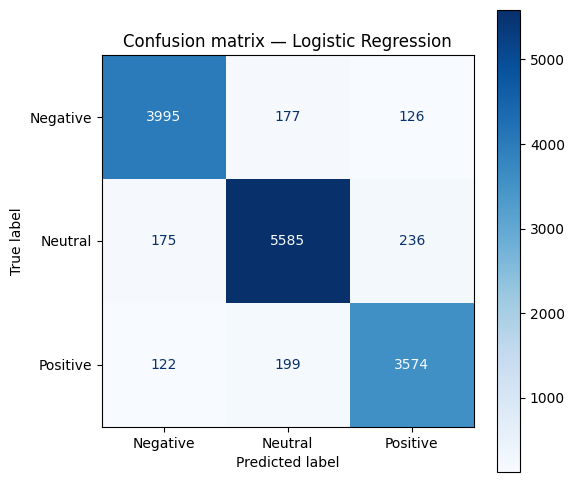

,text,entity,true,pred
37967,see,Battlefield,Positive,Neutral
21482,let's fuck it!!!,CS-GO,Positive,Negative
68066,"the loving the new "" world terminator event "" ...",TomClancysGhostRecon,Positive,Neutral
7100,epic overwatch gameplay i! comments tch.tv / m...,Overwatch,Positive,Neutral
2600,<unk>'m in agreement with this name | <unk>ا<u...,CallOfDutyBlackopsColdWar,Positive,Neutral
3974,here we go.,CallOfDutyBlackopsColdWar,Positive,Neutral
38139,we didn't deserve battlefield 1.,Battlefield,Positive,Negative
50194,2nd starts time playing through red letter dea...,RedDeadRedemption(RDR),Positive,Neutral
39722,nan,PlayerUnknownsBattlegrounds(PUBG),Positive,Neutral
42799,hello @ twitchsupport i'm having problems with...,Verizon,Positive,Negative


In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
print("Macro F1:", f1_score(y_test, best.predict(X_test), average="macro"))

# confusion matrix (visual)
labels = sorted(np.unique(y))
cm = confusion_matrix(y_test, best.predict(X_test), labels=labels)
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues")
plt.title("Confusion matrix — Logistic Regression")
plt.show()

# Error analysis - show some false negatives for 'Positive' predicted as 'Neutral' / 'Negative'
test_df = X_test.copy()
test_df['true'] = y_test
test_df['pred'] = best.predict(X_test)
fn = test_df[(test_df["true"]=="Positive") & (test_df["pred"]!="Positive")].sample(min(10,len(test_df[(test_df["true"]=="Positive") & (test_df["pred"]!="Positive")])))
display(fn)

In [12]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_extraction.text import TfidfVectorizer

tf = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=3)
X_train_tfidf = tf.fit_transform(X_train['text'])
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train_tfidf, y_train)
print("Resampled class counts:", pd.Series(y_res).value_counts())

# then train classifier on X_res (sparse matrix) directly
clf = LogisticRegression(max_iter=2000)
clf.fit(X_res, y_res)

# Evaluate on the test set
X_test_tfidf = tf.transform(X_test['text'])
y_pred = clf.predict(X_test_tfidf)
print("\nClassification Report (with oversampling):")
print(classification_report(y_test, y_pred))

Resampled class counts: Negative    23983
Neutral     23983
Positive    23983
Name: count, dtype: int64

Classification Report (with oversampling):
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89      4298
     Neutral       0.89      0.89      0.89      5996
    Positive       0.86      0.88      0.87      3895

    accuracy                           0.88     14189
   macro avg       0.88      0.88      0.88     14189
weighted avg       0.88      0.88      0.88     14189



**Save the best model**

In [13]:
# Save best pipeline
joblib.dump(best, "sentiment_model.pkl")
print("Model saved as sentiment_model.pkl")

Model saved as sentiment_model.pkl
